In [3]:
pacman::p_load(quanteda,
               quanteda.textstats,
               dplyr,
               lsa,
               stringr)

In [2]:
tokens_all <- readRDS("all_toks_ngram_0412.rds")

In [ ]:
ndoc(tokens_all)

In [ ]:
table(docvars(tokens_all)$Source)

## Run Topic Models on Sample

In [5]:
## randomly sample 50000 articles from the corpus
set.seed(123)
tokens_sample <- tokens_sample(tokens_all, 50000)

In [6]:
dfm_all <-
    dfm(tokens_sample) %>%
    dfm_trim(min_termfreq = 50) ## at least appear 50 times in the sample

In [7]:
## make sure no empty rows
dfm_all <- dfm_subset(dfm_all, ntoken(dfm_all) != 0)

In [9]:
saveRDS(dfm_all, "dfm_all_compressed_0412.rds", compress = "xz")

## Select number of topics

In [2]:
library(topicmodels)
library("ldatuning")
library("parallel")

In [ ]:
# Define file paths
log_file <- "process_progress_log.txt"
flag_file <- "stop_flag.txt"

# Function to log progress with formatted Eastern Time
log_progress <- function(message, log_file) {
  formatted_time <- format(Sys.time(), "%Y-%m-%d %H:%M:%S", tz = "America/New_York")
  cat(message, formatted_time, "\n", file = log_file, append = TRUE)
  flush.console()  # Ensure immediate console output
}

# Function to log progress periodically in Eastern Time
log_progress_periodically <- function(interval, log_file, flag_file) {
  while (!file.exists(flag_file)) {
    Sys.sleep(interval)  # Wait for the specified interval (in seconds)
    log_progress("Still running at: ", log_file)
  }
}

# Initialize the log file
log_progress("Starting process at: ", log_file)

# Start periodic logging in a background process
log_process <- mcparallel(log_progress_periodically(600, log_file, flag_file))  # Log every 600 seconds

# Run the main task
result <- FindTopicsNumber(
  dfm_all,
  topics = c(200, 250, 300, 350, 400, 500),
  metrics = c("CaoJuan2009", "Deveaud2014"),
  method = "Gibbs",
  control = list(seed = 77),
  mc.cores = 8L,
  verbose = TRUE
)

# Create a flag file to stop the logging process
file.create(flag_file)

# Collect and stop the logging process
mccollect(log_process)

# Final log entry after finishing
log_progress("Finished process at: ", log_file)

In [ ]:
saveRDS(result, "Results Files/LDA_result_0412.rds")

In [3]:
result <- readRDS("Results Files/LDA_result_0412.rds")

In [8]:
png("topic_plot.png", width = 800, height = 600)
FindTopicsNumber_plot(result)
dev.off()

png 
  2

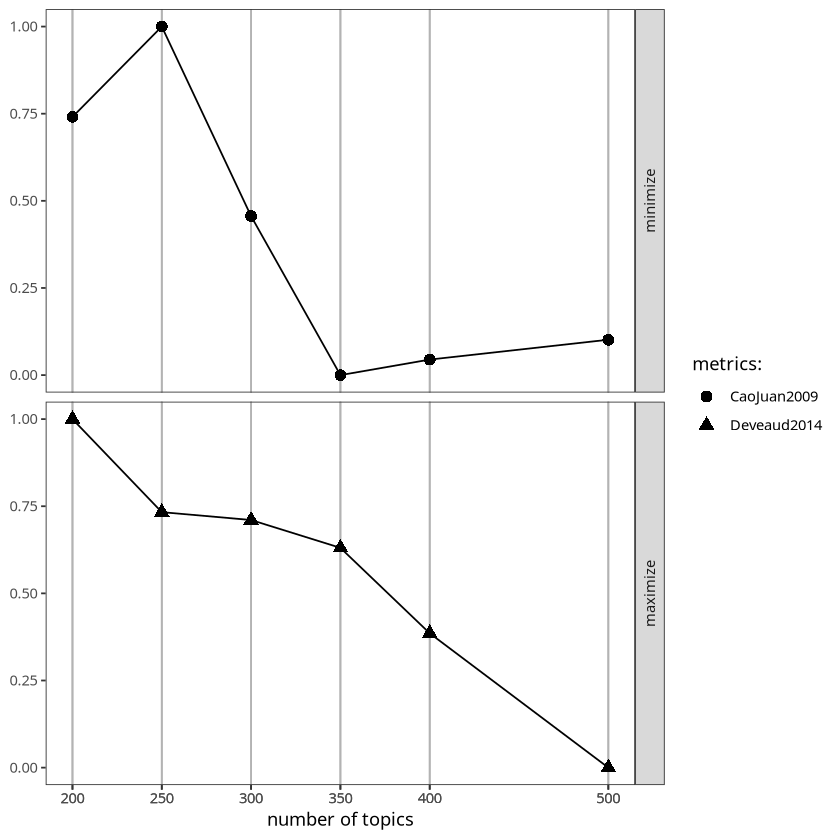

In [13]:
FindTopicsNumber_plot(result)

## Run LDA

In [3]:
dfm_all <- readRDS("dfm_all_compressed_0412.rds")

In [ ]:
# Define file paths
log_file <- "LDA_progress_log.txt"
flag_file <- "stop_flag.txt"

# Function to log progress with formatted Eastern Time
log_progress <- function(message, log_file) {
  formatted_time <- format(Sys.time(), "%Y-%m-%d %H:%M:%S", tz = "America/New_York")
  cat(message, formatted_time, "\n", file = log_file, append = TRUE)
  flush.console()  # Ensure immediate console output
}

# Function to log progress periodically in Eastern Time
log_progress_periodically <- function(interval, log_file, flag_file) {
  while (!file.exists(flag_file)) {
    Sys.sleep(interval)  # Wait for the specified interval (in seconds)
    log_progress("Still running at: ", log_file)
  }
}

# Initialize the log file
log_progress("Starting process at: ", log_file)

# Start periodic logging in a background process
log_process <- mcparallel(log_progress_periodically(600, log_file, flag_file))  # Log every 600 seconds

# Run the main tas
## LDA
all_lda_350 <- LDA(dfm_all, k = 350, method = "Gibbs",  control = list(seed = 1234, iter=500, verbose = 25))

# Create a flag file to stop the logging process
file.create(flag_file)

# Collect and stop the logging process
mccollect(log_process)

# Final log entry after finishing
log_progress("Finished process at: ", log_file)

In [ ]:
saveRDS(all_lda_350, "all_lda_350.rds")

## Create dictionaries

In [1]:
all_lda_350 <- readRDS("all_lda_350.rds")

In [4]:
library(tidytext)

In [5]:
### 1. Match terms with the topic they are most likely to be in
dict_terms <- tidy(all_lda_350, matrix = "beta") %>% 
  group_by(term) %>%
  mutate(ratio = max(beta)/quantile(beta, 0.98, na.rm=TRUE)) %>%  ## find unique terms to each topic
  slice_max(beta, n=1) %>%
  ungroup() %>%
  arrange(topic)

Loading required package: topicmodels



In [10]:
### 2. Select unique terms
unique_terms_350 <- 
  dict_terms %>%
  group_by(topic) %>%
  filter(ratio > 30) %>% ## customary threshold
  slice_max(beta, n=50) %>%
  ungroup()

In [12]:
saveRDS(unique_terms_350, "unique_terms_350.rds")

## Clean Dictionary

I manually examined the topics and deleted incoherent topics and ambiguous words. The results are in the topics_screened_new.csv file.

In [1]:
dict_terms <- read.csv("topics_screened_new.csv")

In [4]:
dict_terms <-
    dict_terms %>%
    filter(decision != "drop")

In [5]:
length(unique(dict_terms$topic))

[1] 133

In [7]:
if (!dir.exists("Results_Files")) {
    dir.create("Results_Files")}

In [8]:
saveRDS(dict_terms, "Results_Files/dict_terms_final_0510.rds")